In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd

In [2]:
#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

# EMIT FULL BANDS DATA

In [3]:
#EMIT_DATA_CSV         = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT.csv"
EMIT_DATA_CSV         = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EMIT_EO_CANOPY.csv"
#EMIT_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT_MISSING.csv"

In [4]:
emit_df = pd.read_csv(EMIT_DATA_CSV)
print(emit_df.shape)

(3880, 316)


## DATA PREPROCESSING

### Select feature columns

In [5]:
non_feature_cols = [
    'dataset',             # metadata
    'EMIT_selected_date',  # metadata
    'EMIT_granule',        # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
    'plant_AGB_kg',        # Target variable
    'diameter',            # Allometric
    'height'               # Allometric
]
target = 'plant_AGB_kg'

feature_cols = [c for c in emit_df.columns if c not in non_feature_cols]

X_belige = emit_df[feature_cols]
y_belige = emit_df[target]

X_belige = X_belige.rename({'tandemx_height_m': 'height'}, axis=1)

print(f"Features : {X_belige.columns}")
print(f"Rows     : {len(emit_df)}")

Features : Index(['plot_id', 'species', 'NDVI', 'NDRE1', 'NDRE2', 'NDRE3', 'NBR', 'MSI',
       'EVI', 'CIrededge',
       ...
       'EMIT_R1357', 'EMIT_R1417', 'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774',
       'EMIT_R1781', 'EMIT_R1789', 'EMIT_R1796', 'simard_height_m', 'height'],
      dtype='object', length=304)
Rows     : 3880


## Create interaction terms.

In [6]:
interact_col_names = ['EVI', 'MSI', 'NBR', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge']
for col in interact_col_names:
    if col in X_belige.columns:
        X_belige[f'height_x_{col}'] = X_belige['height'] * X_belige[col]

In [7]:
interaction_cols = [c for c in X_belige.columns if c.startswith('height_x_')]
print(X_belige[interaction_cols].corrwith(y_belige).abs().sort_values(ascending=False))

height_x_NBR          0.226619
height_x_CIrededge    0.089816
height_x_NDRE1        0.085668
height_x_NDRE2        0.083697
height_x_MSI          0.081560
height_x_EVI          0.077724
height_x_NDRE3        0.026086
dtype: float64


### Handle EMIT columns with NULL data

In [8]:
X_belige = handle_null_columns(X_belige)

Total NULL count           : 17604
Rows with at least one NULL: 1467
Total rows                 : 3880
Percentage                 : 37.8%

NULL count per column in affected rows:
EMIT_R1432    1467
EMIT_R1350    1467
EMIT_R1417    1467
EMIT_R1424    1467
EMIT_R1342    1467
EMIT_R1774    1467
EMIT_R1781    1467
EMIT_R1789    1467
EMIT_R1796    1467
EMIT_R1335    1467
EMIT_R1327    1467
EMIT_R1357    1467
dtype: int64
Dropping 12 columns:
['EMIT_R1327', 'EMIT_R1335', 'EMIT_R1342', 'EMIT_R1350', 'EMIT_R1357', 'EMIT_R1417', 'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774', 'EMIT_R1781', 'EMIT_R1789', 'EMIT_R1796']

NULL count after dropping: 0


These 12 bands are all in the 1300–1800 nm range — the shortwave infrared (SWIR) region. EMIT masks out specific wavelength ranges that are dominated by atmospheric water vapor absorption, where the signal is unreliable. The two main atmospheric water vapor absorption windows in EMIT are:  

~1340 to 1460 nm  ← water vapor absorption band  
~1780 to 1970 nm  ← water vapor absorption band  

All of the 12 null columns listed above, fall squarely in these two ranges. EMIT sets these to nodata for pixels where atmospheric correction failed or where the absorption is too strong to recover reliable surface reflectance.  

The above bands are unreliable by design. Drop them.

### Remove Low Variance Features (cols)

### Remove Features With Weak Correlation to Target

**Show correlations**

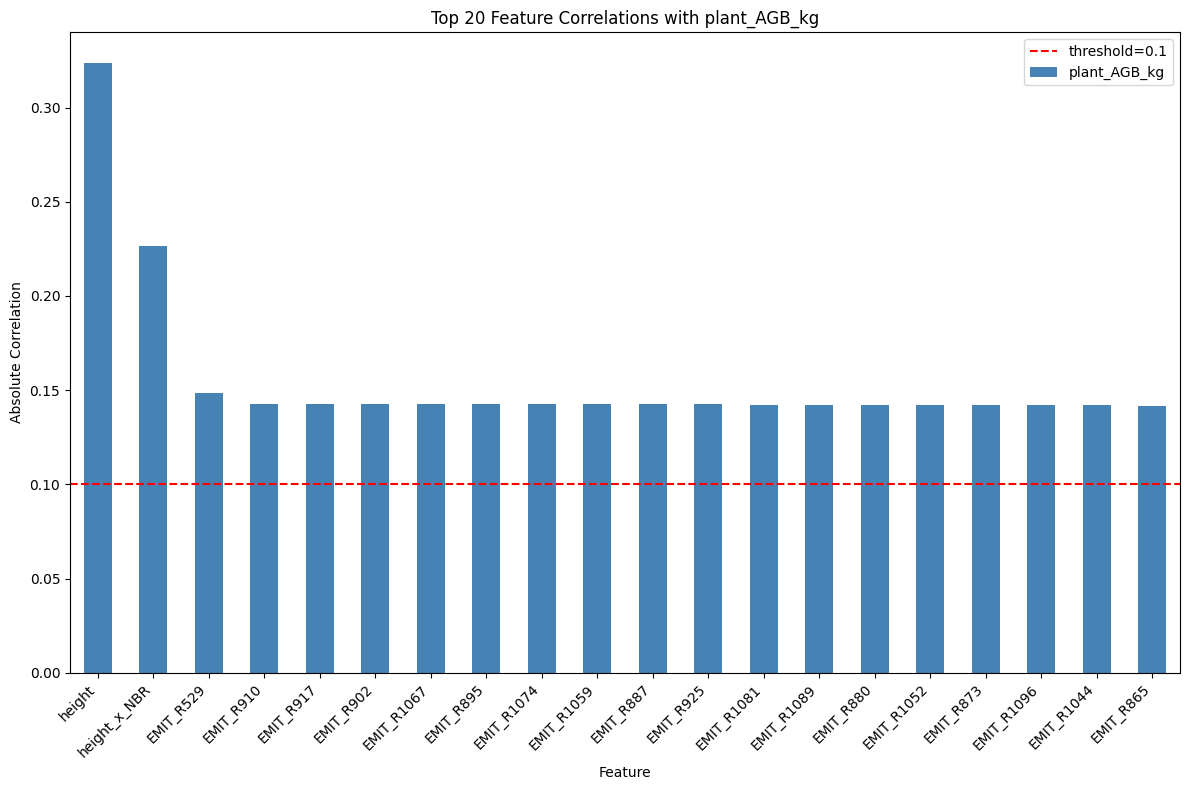

height          0.323760
height_x_NBR    0.226619
EMIT_R529       0.148590
EMIT_R910       0.142650
EMIT_R917       0.142640
EMIT_R902       0.142625
EMIT_R1067      0.142605
EMIT_R895       0.142586
EMIT_R1074      0.142544
EMIT_R1059      0.142453
EMIT_R887       0.142436
EMIT_R925       0.142428
EMIT_R1081      0.142380
EMIT_R1089      0.142266
EMIT_R880       0.142257
EMIT_R1052      0.142205
EMIT_R873       0.142132
EMIT_R1096      0.142024
EMIT_R1044      0.142020
EMIT_R865       0.141829
Name: plant_AGB_kg, dtype: float64


In [9]:
numerical_cols = get_numerical_cols(X_belige)

target_corr = plot_correlation_matrix(X_belige[numerical_cols],
                                      y_belige,
                                      top_n=20)
print(target_corr)

**EMIT bands clustered around 0.142**  
 - All EMIT bands show nearly identical correlations in a very tight range of 0.1416 to 0.1427. This is suspicious
 - Genuine spectral variation across 285 bands should produce more spread in correlations
 - The uniformity suggests these bands are highly correlated with each other and likely all capturing the same underlying signal — probably canopy reflectance in the NIR plateau region around 900-1100nm where vegetation reflectance is high and relatively flat
 - The bands shown — EMIT_R865 through EMIT_R1104 — are all in the NIR region. They are essentially measuring the same thing from slightly different wavelengths

**Remove uncorrelated numerical columns**

corr_threshold = 0.05
X_belige = remove_uncorrelated_numerical_cols(X_belige, y_belige,
                                       threshold=corr_threshold,
                                       exclude_cols=['height'])
assert X_belige is not None

X_belige = remove_uncorrelated_categorical_cols(X_belige, y_belige)
assert X_belige is not None

# TEST PARAMETERS

## TEST FEATURES

In [10]:
struct_features   = ['height']
interaction_terms = [c for c in X_belige.columns if c.startswith('height_x_')]
emit_indices      = ['NDVI', 'NDRE1', 'NDRE2', 'NDRE3', 'NBR', 'MSI', 'EVI', 'CIrededge']
emit_cols         = [c for c in X_belige.columns if c.startswith('EMIT')]

# NIR removed — no standalone NIR in EMIT
top_spectral_1 = ['height', 'EVI', 'NBR', 'MSI', 'NDRE1']
top_spectral_2 = ['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1']
redband_1      = ['height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge']
redband_2      = ['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge']

emit_features_list = [
    emit_cols,
    emit_cols + struct_features,
    emit_cols + interaction_terms,

    emit_indices,
    emit_indices + struct_features,
    emit_indices + interaction_terms,

    emit_cols + emit_indices,
    emit_cols + emit_indices + struct_features,
    emit_cols + emit_indices + interaction_terms,

    emit_cols + emit_indices + struct_features,
    emit_cols + emit_indices + struct_features + interaction_terms,

    top_spectral_1,
    top_spectral_1 + struct_features,
    top_spectral_1 + interaction_terms,

    top_spectral_2,
    top_spectral_2 + struct_features,
    top_spectral_2 + interaction_terms,

    redband_1,
    redband_1 + struct_features,
    redband_1 + interaction_terms,

    redband_2,
    redband_2 + struct_features,
    redband_2 + interaction_terms,
]

test_cv = 5

## Create plot groups

In [11]:
# Retain the groups/plot_id for splitting the data based on groups.
if 'plot_id' in X_belige.columns:
    plot_groups_belige = X_belige['plot_id'].copy()
    X_belige = X_belige.drop(columns=['plot_id'])

site_groups_belige = plot_groups_belige.map(lambda x: x.rsplit('_', maxsplit=1)[0])

near_zero_sites_belige, high_agb_sites_belige,\
    near_zero_plots_belige, high_agb_plots_belige = get_low_and_high_agb_plots(y_belige,
                                                                               plot_groups_belige)

grp_belige = GROUP_INFO(near_zero_sites_belige, high_agb_sites_belige,
                        near_zero_plots_belige, high_agb_plots_belige,
                        groups=plot_groups_belige,
                        cv=test_cv)

High-AGB threshold  : 104.49 kg
Near-zero threshold : 0.004134

Near-zero variance plots:
  Big Creek_1               : log var = 0.000036
  Big Creek_4               : log var = 0.000032
  Frenchman Caye_1          : log var = 0.000753
  Frenchman Caye_2          : log var = 0.000381
  Frenchman Caye_3          : log var = 0.000693
  Frenchman Caye_4          : log var = 0.001306
  Frenchman Caye_5          : log var = 0.001283
  Frenchman Caye_6          : log var = 0.000158
  Shipstern Lagoon_1        : log var = 0.001064
  Shipstern Lagoon_3        : log var = 0.000232
  Shipstern Lagoon_4        : log var = 0.000113
  Shipstern Lagoon_5        : log var = 0.000052
  Shipstern Lagoon_6        : log var = 0.000135

High-AGB plots:
  Channel Caye_1            : max AGB = 310.9 kg
  Channel Caye_2            : max AGB = 206.4 kg
  Channel Caye_3            : max AGB = 427.2 kg
  Channel Caye_4            : max AGB = 237.6 kg
  Channel Caye_5            : max AGB = 170.4 kg
  Channel C

In [12]:
global_experiment_list = {}

# LINEAR REGRESSION

In [13]:
lin_emit_no_groups = {}
run_experiment(X_belige, y_belige,
               is_groups=False, group_info=grp_belige,
               features_list=emit_features_list,
               model_type="linear",
               is_grid=False,
               is_stratified=False,
               experiments=lin_emit_no_groups,
               global_experiment_list=global_experiment_list)


[1/92]

 EXPERIMENT-1. ,Model: LINEAR REGRESSION, Grouping? No, Hypertuned? No, Features: ['EMIT bands (280)']
Test R²     : 0.1196
Test RMSE   : 15.82 kg
Train R² (log scale): 0.3631
Train R² (orig scale): 0.1653
Train RMSE  : 15.29 kg
Num rows    : 3104
Num Features: 280

 Cross-validation ---
CV R² mean: 0.3406
CV R² std : 0.0207
CV scores : [0.36  0.306 0.328 0.348 0.36 ]
 EVALUATION: EXPERIMENT-1. ,Model: LINEAR REGRESSION, Grouping? No, Hypertuned? No, Features: ['EMIT bands (280)']

Test set:
  R²   : 0.120
  RMSE : 15.82 kg

 ✅ Test R² is positive (0.120)

Regular CrossValidation:
  Mean   : 0.341
  Std    : 0.021
  Scores : [0.36  0.306 0.328 0.348 0.36 ]
 ✅ CV mean is positive (0.341)
  ✅ Train/test R² gap acceptable (gap: 0.046)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[2/92]

 EXPERIMENT-2. ,Model: RIDGE REGRESSION, Grouping? No, Hypertuned? No, Features: ['EMIT bands (280)']
Test R²     : 0.1167
Test RMSE   : 15.85 kg
Train R² (

In [14]:
lin_emit_groups = {}
run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=emit_features_list,
               model_type="linear",
               is_grid=False,
               is_stratified=False,
               experiments=lin_emit_groups,
               global_experiment_list=global_experiment_list)


[1/92]

 EXPERIMENT-1. ,Model: LINEAR REGRESSION, Grouping? Yes, Hypertuned? No, Features: ['EMIT bands (280)']
Test R²     : 0.2802
Test RMSE   : 3.92 kg
Train R² (log scale): 0.3637
Train R² (orig scale): 0.1458
Train RMSE  : 17.16 kg
Num rows    : 3100
Num Features: 280

 Cross-validation ---
CV R² mean: -4.6924
CV R² std : 8.6501
CV scores : [ -0.117  -0.602  -0.137  -0.619 -21.987]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2030
Grouped CV R² std : 0.2287
Grouped CV scores : [-0.078 -0.184  0.225 -0.053  0.359  0.531  0.497  0.243  0.196  0.294]
 EVALUATION: EXPERIMENT-1. ,Model: LINEAR REGRESSION, Grouping? Yes, Hypertuned? No, Features: ['EMIT bands (280)']

Test set:
  R²   : 0.280
  RMSE : 3.92 kg

 ✅ Test R² is positive (0.280)

Regular CrossValidation:
  Mean   : -4.692
  Std    : 8.650
  Scores : [ -0.117  -0.602  -0.137  -0.619 -21.987]
 ❌ CV mean is negative (-4.692)

Grouped CrossValidation:
  Big Creek_5          :  -0.078  ⚠️  fold contamination — Channel Cay

# RANDOM FOREST.

## No groups

In [15]:
rf_emit_no_groups_no_grid ={}
run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=emit_features_list,
               model_type="rf",
               is_grid=False,
               is_stratified=False,
               experiments=rf_emit_no_groups_no_grid,
               global_experiment_list=global_experiment_list)


[1/23]

 EXPERIMENT-1. ,Model: RANDOM FOREST, Grouping? Yes, Hypertuned? No, Features: ['EMIT bands (280)']
Test R²     : 0.2793
Test RMSE   : 3.92 kg
Train R² (log scale): 0.3637
Train R² (orig scale): 0.1459
Train RMSE  : 17.16 kg
Num rows    : 3100
Num Features: 280

 Cross-validation ---
CV R² mean: -0.3186
CV R² std : 0.5142
CV scores : [-0.013  0.118 -0.213 -0.165 -1.32 ]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2447
Grouped CV R² std : 0.1937
Grouped CV scores : [-0.071  0.156  0.169 -0.02   0.449  0.512  0.52   0.276  0.199  0.257]
 EVALUATION: EXPERIMENT-1. ,Model: RANDOM FOREST, Grouping? Yes, Hypertuned? No, Features: ['EMIT bands (280)']

Test set:
  R²   : 0.279
  RMSE : 3.92 kg

 ✅ Test R² is positive (0.279)

Regular CrossValidation:
  Mean   : -0.319
  Std    : 0.514
  Scores : [-0.013  0.118 -0.213 -0.165 -1.32 ]
 ❌ CV mean is negative (-0.319)

Grouped CrossValidation:
  Big Creek_5          :  -0.071  ⚠️  fold contamination — Channel Caye_1 in same fold
 

In [16]:
tab_df = tabulate_results(rf_emit_no_groups_no_grid)

,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV scores,-ve Folds,Group CV-Test Gap,model,features,grouping,stratified,hyperparameter,verdict
0,15,0.3281,3.78,0.1863,16.75,-0.1327,0.5296,"[-0.033, 0.62, 0.032, -0.266, -1.017]",0.3343,0.1568,"[0.19, 0.285, 0.351, 0.013, 0.464, 0.6, 0.506, 0.322, 0.306, 0.305]",none,0.0062,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
1,17,0.3275,3.79,0.1864,16.75,-0.1239,0.4997,"[-0.048, 0.608, 0.012, -0.246, -0.945]",0.3335,0.1619,"[0.138, 0.284, 0.352, 0.02, 0.472, 0.604, 0.505, 0.327, 0.307, 0.326]",none,0.006,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
2,9,0.3592,3.69,0.1866,16.75,-0.1505,0.4657,"[-0.257, 0.309, 0.336, -0.201, -0.939]",0.3136,0.1911,"[-0.025, 0.334, 0.345, -0.011, 0.48, 0.587, 0.506, 0.348, 0.31, 0.261]","2 (Big Creek_5, Big Creek_3)",0.0455,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
3,11,0.3578,3.7,0.1866,16.75,-0.1963,0.6306,"[-0.246, 0.474, 0.319, -0.205, -1.324]",0.3083,0.1943,"[-0.05, 0.318, 0.343, 0.002, 0.472, 0.593, 0.505, 0.353, 0.311, 0.236]",1 (Big Creek_5),0.0495,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
4,8,0.3621,3.69,0.1861,16.75,-0.3622,0.9341,"[-0.237, 0.536, 0.307, -0.297, -2.12]",0.3042,0.1836,"[-0.016, 0.301, 0.324, 0.016, 0.453, 0.586, 0.507, 0.342, 0.312, 0.218]",1 (Big Creek_5),0.0579,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1']",Yes,No,No,❌ REJECTED
5,10,0.3614,3.69,0.1865,16.75,-0.3762,0.9533,"[-0.252, 0.538, 0.304, -0.3, -2.172]",0.3002,0.1907,"[-0.053, 0.3, 0.323, 0.014, 0.452, 0.586, 0.508, 0.342, 0.311, 0.219]",1 (Big Creek_5),0.0612,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge']",Yes,No,No,❌ REJECTED
6,12,0.2652,3.96,0.1658,16.96,-0.184,0.5451,"[-0.008, 0.625, -0.349, -0.127, -1.061]",0.2895,0.1675,"[0.163, 0.173, 0.248, -0.014, 0.444, 0.594, 0.485, 0.274, 0.242, 0.286]",1 (Big Creek_3),0.0243,RANDOM FOREST,"['height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
7,14,0.2729,3.94,0.1658,16.96,-0.1591,0.5175,"[0.002, 0.639, -0.322, -0.149, -0.965]",0.2843,0.1703,"[0.119, 0.181, 0.244, -0.012, 0.441, 0.595, 0.484, 0.268, 0.249, 0.274]",1 (Big Creek_3),0.0113,RANDOM FOREST,"['height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
8,15,0.2743,3.93,0.1658,16.96,-0.2844,0.6661,"[0.016, 0.575, -0.324, -0.227, -1.461]",0.2746,0.1682,"[0.16, 0.159, 0.224, -0.016, 0.393, 0.599, 0.493, 0.237, 0.253, 0.244]",1 (Big Creek_3),0.0003,RANDOM FOREST,"['NDVI', 'NDRE1', 'NDRE2', 'NDRE3', 'NBR', 'MSI', 'EVI', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
9,6,0.256,3.98,0.1658,16.96,-0.1829,0.5406,"[-0.118, 0.47, -0.101, 0.011, -1.176]",0.2615,0.1974,"[-0.077, 0.253, 0.243, -0.028, 0.442, 0.582, 0.485, 0.284, 0.232, 0.2]","2 (Big Creek_5, Big Creek_3)",0

## With groups + No tuning

In [17]:
rf_emit_groups_no_grid = {}
run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=emit_features_list,
               model_type="rf",
               is_grid=False,
               is_stratified=False,
               experiments=rf_emit_groups_no_grid,
               global_experiment_list=global_experiment_list)


[1/23]

 EXPERIMENT-1. ,Model: RANDOM FOREST, Grouping? Yes, Hypertuned? No, Features: ['EMIT bands (280)']
Test R²     : 0.2793
Test RMSE   : 3.92 kg
Train R² (log scale): 0.3637
Train R² (orig scale): 0.1459
Train RMSE  : 17.16 kg
Num rows    : 3100
Num Features: 280

 Cross-validation ---
CV R² mean: -0.3186
CV R² std : 0.5142
CV scores : [-0.013  0.118 -0.213 -0.165 -1.32 ]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2447
Grouped CV R² std : 0.1937
Grouped CV scores : [-0.071  0.156  0.169 -0.02   0.449  0.512  0.52   0.276  0.199  0.257]
 EVALUATION: EXPERIMENT-1. ,Model: RANDOM FOREST, Grouping? Yes, Hypertuned? No, Features: ['EMIT bands (280)']

Test set:
  R²   : 0.279
  RMSE : 3.92 kg

 ✅ Test R² is positive (0.279)

Regular CrossValidation:
  Mean   : -0.319
  Std    : 0.514
  Scores : [-0.013  0.118 -0.213 -0.165 -1.32 ]
 ❌ CV mean is negative (-0.319)

Grouped CrossValidation:
  Big Creek_5          :  -0.071  ⚠️  fold contamination — Channel Caye_1 in same fold
 

In [18]:
tab_df = tabulate_results(rf_emit_groups_no_grid)

,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV scores,-ve Folds,Group CV-Test Gap,model,features,grouping,stratified,hyperparameter,verdict
0,15,0.3281,3.78,0.1863,16.75,-0.1327,0.5296,"[-0.033, 0.62, 0.032, -0.266, -1.017]",0.3343,0.1568,"[0.19, 0.285, 0.351, 0.013, 0.464, 0.6, 0.506, 0.322, 0.306, 0.305]",none,0.0062,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
1,17,0.3275,3.79,0.1864,16.75,-0.1239,0.4997,"[-0.048, 0.608, 0.012, -0.246, -0.945]",0.3335,0.1619,"[0.138, 0.284, 0.352, 0.02, 0.472, 0.604, 0.505, 0.327, 0.307, 0.326]",none,0.006,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
2,9,0.3592,3.69,0.1866,16.75,-0.1505,0.4657,"[-0.257, 0.309, 0.336, -0.201, -0.939]",0.3136,0.1911,"[-0.025, 0.334, 0.345, -0.011, 0.48, 0.587, 0.506, 0.348, 0.31, 0.261]","2 (Big Creek_5, Big Creek_3)",0.0455,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
3,11,0.3578,3.7,0.1866,16.75,-0.1963,0.6306,"[-0.246, 0.474, 0.319, -0.205, -1.324]",0.3083,0.1943,"[-0.05, 0.318, 0.343, 0.002, 0.472, 0.593, 0.505, 0.353, 0.311, 0.236]",1 (Big Creek_5),0.0495,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
4,8,0.3621,3.69,0.1861,16.75,-0.3622,0.9341,"[-0.237, 0.536, 0.307, -0.297, -2.12]",0.3042,0.1836,"[-0.016, 0.301, 0.324, 0.016, 0.453, 0.586, 0.507, 0.342, 0.312, 0.218]",1 (Big Creek_5),0.0579,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1']",Yes,No,No,❌ REJECTED
5,10,0.3614,3.69,0.1865,16.75,-0.3762,0.9533,"[-0.252, 0.538, 0.304, -0.3, -2.172]",0.3002,0.1907,"[-0.053, 0.3, 0.323, 0.014, 0.452, 0.586, 0.508, 0.342, 0.311, 0.219]",1 (Big Creek_5),0.0612,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge']",Yes,No,No,❌ REJECTED
6,12,0.2652,3.96,0.1658,16.96,-0.184,0.5451,"[-0.008, 0.625, -0.349, -0.127, -1.061]",0.2895,0.1675,"[0.163, 0.173, 0.248, -0.014, 0.444, 0.594, 0.485, 0.274, 0.242, 0.286]",1 (Big Creek_3),0.0243,RANDOM FOREST,"['height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
7,14,0.2729,3.94,0.1658,16.96,-0.1591,0.5175,"[0.002, 0.639, -0.322, -0.149, -0.965]",0.2843,0.1703,"[0.119, 0.181, 0.244, -0.012, 0.441, 0.595, 0.484, 0.268, 0.249, 0.274]",1 (Big Creek_3),0.0113,RANDOM FOREST,"['height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
8,15,0.2743,3.93,0.1658,16.96,-0.2844,0.6661,"[0.016, 0.575, -0.324, -0.227, -1.461]",0.2746,0.1682,"[0.16, 0.159, 0.224, -0.016, 0.393, 0.599, 0.493, 0.237, 0.253, 0.244]",1 (Big Creek_3),0.0003,RANDOM FOREST,"['NDVI', 'NDRE1', 'NDRE2', 'NDRE3', 'NBR', 'MSI', 'EVI', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
9,6,0.256,3.98,0.1658,16.96,-0.1829,0.5406,"[-0.118, 0.47, -0.101, 0.011, -1.176]",0.2615,0.1974,"[-0.077, 0.253, 0.243, -0.028, 0.442, 0.582, 0.485, 0.284, 0.232, 0.2]","2 (Big Creek_5, Big Creek_3)",0

## With groups + Tuning

In [19]:
rf_emit_groups_grid = {}
run_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               features_list=emit_features_list,
               model_type="rf",
               is_grid=False,
               is_stratified=False,
               experiments=rf_emit_groups_grid,
               global_experiment_list=global_experiment_list)


[1/23]

 EXPERIMENT-1. ,Model: RANDOM FOREST, Grouping? Yes, Hypertuned? No, Features: ['EMIT bands (280)']
Test R²     : 0.2793
Test RMSE   : 3.92 kg
Train R² (log scale): 0.3637
Train R² (orig scale): 0.1459
Train RMSE  : 17.16 kg
Num rows    : 3100
Num Features: 280

 Cross-validation ---
CV R² mean: -0.3186
CV R² std : 0.5142
CV scores : [-0.013  0.118 -0.213 -0.165 -1.32 ]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2447
Grouped CV R² std : 0.1937
Grouped CV scores : [-0.071  0.156  0.169 -0.02   0.449  0.512  0.52   0.276  0.199  0.257]
 EVALUATION: EXPERIMENT-1. ,Model: RANDOM FOREST, Grouping? Yes, Hypertuned? No, Features: ['EMIT bands (280)']

Test set:
  R²   : 0.279
  RMSE : 3.92 kg

 ✅ Test R² is positive (0.279)

Regular CrossValidation:
  Mean   : -0.319
  Std    : 0.514
  Scores : [-0.013  0.118 -0.213 -0.165 -1.32 ]
 ❌ CV mean is negative (-0.319)

Grouped CrossValidation:
  Big Creek_5          :  -0.071  ⚠️  fold contamination — Channel Caye_1 in same fold
 

In [26]:
tab_df = tabulate_results(rf_emit_groups_grid)

,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV scores,-ve Folds,Group CV-Test Gap,model,features,grouping,stratified,hyperparameter,verdict
0,15,0.3281,3.78,0.1863,16.75,-0.1327,0.5296,"[-0.033, 0.62, 0.032, -0.266, -1.017]",0.3343,0.1568,"[0.19, 0.285, 0.351, 0.013, 0.464, 0.6, 0.506, 0.322, 0.306, 0.305]",none,0.0062,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
1,17,0.3275,3.79,0.1864,16.75,-0.1239,0.4997,"[-0.048, 0.608, 0.012, -0.246, -0.945]",0.3335,0.1619,"[0.138, 0.284, 0.352, 0.02, 0.472, 0.604, 0.505, 0.327, 0.307, 0.326]",none,0.006,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
2,9,0.3592,3.69,0.1866,16.75,-0.1505,0.4657,"[-0.257, 0.309, 0.336, -0.201, -0.939]",0.3136,0.1911,"[-0.025, 0.334, 0.345, -0.011, 0.48, 0.587, 0.506, 0.348, 0.31, 0.261]","2 (Big Creek_5, Big Creek_3)",0.0455,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
3,11,0.3578,3.7,0.1866,16.75,-0.1963,0.6306,"[-0.246, 0.474, 0.319, -0.205, -1.324]",0.3083,0.1943,"[-0.05, 0.318, 0.343, 0.002, 0.472, 0.593, 0.505, 0.353, 0.311, 0.236]",1 (Big Creek_5),0.0495,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
4,8,0.3621,3.69,0.1861,16.75,-0.3622,0.9341,"[-0.237, 0.536, 0.307, -0.297, -2.12]",0.3042,0.1836,"[-0.016, 0.301, 0.324, 0.016, 0.453, 0.586, 0.507, 0.342, 0.312, 0.218]",1 (Big Creek_5),0.0579,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1']",Yes,No,No,❌ REJECTED
5,10,0.3614,3.69,0.1865,16.75,-0.3762,0.9533,"[-0.252, 0.538, 0.304, -0.3, -2.172]",0.3002,0.1907,"[-0.053, 0.3, 0.323, 0.014, 0.452, 0.586, 0.508, 0.342, 0.311, 0.219]",1 (Big Creek_5),0.0612,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge']",Yes,No,No,❌ REJECTED
6,12,0.2652,3.96,0.1658,16.96,-0.184,0.5451,"[-0.008, 0.625, -0.349, -0.127, -1.061]",0.2895,0.1675,"[0.163, 0.173, 0.248, -0.014, 0.444, 0.594, 0.485, 0.274, 0.242, 0.286]",1 (Big Creek_3),0.0243,RANDOM FOREST,"['height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
7,14,0.2729,3.94,0.1658,16.96,-0.1591,0.5175,"[0.002, 0.639, -0.322, -0.149, -0.965]",0.2843,0.1703,"[0.119, 0.181, 0.244, -0.012, 0.441, 0.595, 0.484, 0.268, 0.249, 0.274]",1 (Big Creek_3),0.0113,RANDOM FOREST,"['height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
8,15,0.2743,3.93,0.1658,16.96,-0.2844,0.6661,"[0.016, 0.575, -0.324, -0.227, -1.461]",0.2746,0.1682,"[0.16, 0.159, 0.224, -0.016, 0.393, 0.599, 0.493, 0.237, 0.253, 0.244]",1 (Big Creek_3),0.0003,RANDOM FOREST,"['NDVI', 'NDRE1', 'NDRE2', 'NDRE3', 'NBR', 'MSI', 'EVI', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
9,6,0.256,3.98,0.1658,16.96,-0.1829,0.5406,"[-0.118, 0.47, -0.101, 0.011, -1.176]",0.2615,0.1974,"[-0.077, 0.253, 0.243, -0.028, 0.442, 0.582, 0.485, 0.284, 0.232, 0.2]","2 (Big Creek_5, Big Creek_3)",0

# FIND THE BEST EXPERIMENT SO FAR.

## SUMMARY OF EXPERIMENTS

In [25]:
%run Model_functions.ipynb
best_results = filter_best_experiments(global_experiment_list, grouped_only=True)
tab_df = tabulate_results(best_results, grouped_only=True)

Found 92 experiments — best first.


,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,CV scores,Group CV R² Mean,Group CV R² Std,Group CV scores,-ve Folds,Group CV-Test Gap,model,features,grouping,stratified,hyperparameter,verdict
0,15,0.3281,3.78,0.1863,16.75,-0.1327,0.5296,"[-0.033, 0.62, 0.032, -0.266, -1.017]",0.3343,0.1568,"[0.19, 0.285, 0.351, 0.013, 0.464, 0.6, 0.506, 0.322, 0.306, 0.305]",none,0.0062,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
1,17,0.3275,3.79,0.1864,16.75,-0.1239,0.4997,"[-0.048, 0.608, 0.012, -0.246, -0.945]",0.3335,0.1619,"[0.138, 0.284, 0.352, 0.02, 0.472, 0.604, 0.505, 0.327, 0.307, 0.326]",none,0.006,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
2,9,0.3592,3.69,0.1866,16.75,-0.1505,0.4657,"[-0.257, 0.309, 0.336, -0.201, -0.939]",0.3136,0.1911,"[-0.025, 0.334, 0.345, -0.011, 0.48, 0.587, 0.506, 0.348, 0.31, 0.261]","2 (Big Creek_5, Big Creek_3)",0.0455,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
3,11,0.3578,3.7,0.1866,16.75,-0.1963,0.6306,"[-0.246, 0.474, 0.319, -0.205, -1.324]",0.3083,0.1943,"[-0.05, 0.318, 0.343, 0.002, 0.472, 0.593, 0.505, 0.353, 0.311, 0.236]",1 (Big Creek_5),0.0495,RANDOM FOREST,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
4,17,0.2934,3.88,0.0577,18.03,0.1395,0.3309,"[0.012, 0.644, 0.265, -0.371, 0.148]",0.3046,0.1725,"[0.051, 0.264, 0.254, 0.052, 0.359, 0.57, 0.603, 0.288, 0.267, 0.338]",none,0.0112,RIDGE REGRESSION,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,✅ ACCEPTABLE
5,15,0.2919,3.88,0.0576,18.03,-0.0432,0.2548,"[0.012, -0.306, 0.267, -0.369, 0.18]",0.3033,0.1734,"[0.042, 0.262, 0.253, 0.053, 0.359, 0.569, 0.602, 0.29, 0.265, 0.338]",none,0.0113,RIDGE REGRESSION,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']",Yes,No,No,⚠️ MARGINAL (grouped CV clean but regular CV negative)
6,8,0.3151,3.82,0.0576,18.03,0.1569,0.1808,"[-0.006, 0.42, 0.284, -0.07, 0.158]",0.2991,0.1811,"[0.044, 0.269, 0.224, 0.034, 0.361, 0.558, 0.633, 0.289, 0.25, 0.328]",none,0.016,RIDGE REGRESSION,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1']",Yes,No,No,✅ ACCEPTABLE
7,9,0.3158,3.82,0.0565,18.04,0.1874,0.2267,"[-0.008, 0.567, 0.285, -0.065, 0.158]",0.2984,0.1846,"[0.025, 0.267, 0.226, 0.032, 0.368, 0.561, 0.632, 0.291, 0.252, 0.33]",none,0.0174,RIDGE REGRESSION,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height']",Yes,No,No,✅ ACCEPTABLE
8,8,0.3149,3.82,0.0555,18.05,0.1104,0.1108,"[-0.01, 0.296, 0.173, 0.061, 0.033]",0.294,0.1857,"[0.017, 0.262, 0.224, 0.025, 0.359, 0.559, 0.629, 0.283, 0.25, 0.33]",none,0.0209,ELASTICNET REGRESSION,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1']",Yes,No,No,✅ ACCEPTABLE
9,9,0.315,3.82,0.0551,18.05,0.1197,0.106,"[-0.01, 0.297, 0.173, 0.069, 0.07]",0.294,0.1859,"[0.016, 0.262, 0.225, 0.025, 0.36, 0.559, 0.629, 0.283, 0.251, 0.33]",none,0.021,ELASTICNET REGRESSION,"['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'height']",Yes,No,No,✅ ACCEPTABLE


## BEST MODEL

In [27]:
%run Model_functions.ipynb
best_result = best_results[0][1]
print_experiment(best_result)


 EXPERIMENT
  Model                : RIDGE REGRESSION
  Features             : ['species', 'height', 'EVI', 'NBR', 'MSI', 'NDRE1', 'NDRE2', 'CIrededge', 'height_x_EVI', 'height_x_MSI', 'height_x_NBR', 'height_x_NDRE1', 'height_x_NDRE2', 'height_x_NDRE3', 'height_x_CIrededge']
  Num Features         : 17
  Grouping             : Yes
  Stratified split     : No
  Hyperparameter tuned : No
  Test R²              : 0.2934
  Test RMSE            : 3.88 kg
  Train R² (log scale) : nan
  Train R² (orig scale): 0.0577
  Train RMSE           : 18.03 kg

 Cross-validation ---
  CV R² mean: 0.1395
  CV R² std : 0.3309
  CV scores : [ 0.012  0.644  0.265 -0.371  0.148]

 Grouped Cross-validation ---
  Grouped CV R² mean : 0.3046
  Grouped CV R² std  : 0.1725
  Grouped CV scores  : [0.051 0.264 0.254 0.052 0.359 0.57  0.603 0.288 0.267 0.338]

  Fold plots       : [['Big Creek_5', 'Channel Caye_1', 'Channel Caye_4', 'New River_2', 'Turneffe Atoll_3'], ['Frenchman Caye_6', 'Gra Gra Lagoon_6', 'Hick

### Residual analysis

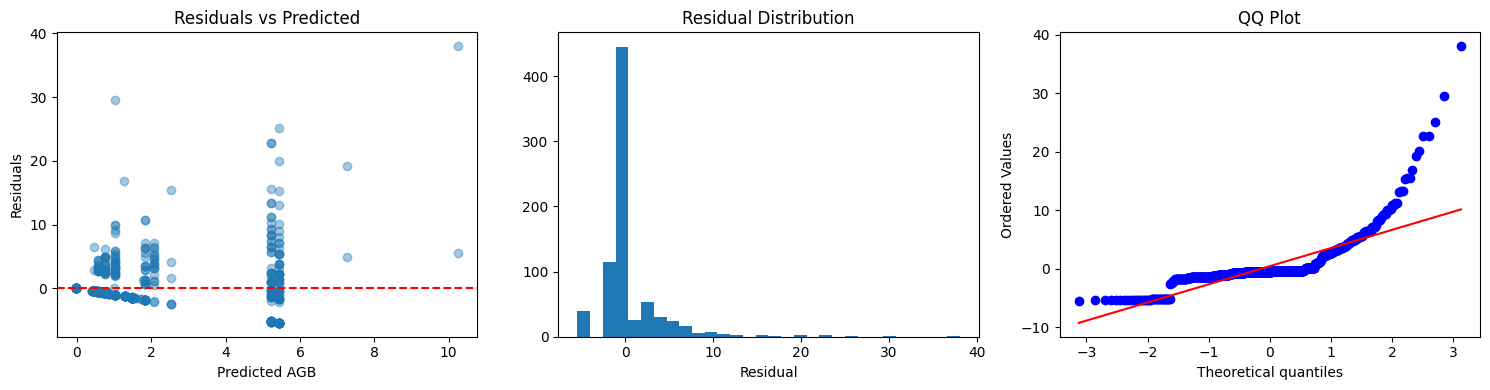

In [28]:
y_pred    = best_result["y_pred"]
residuals = best_result["residuals"]

residual_analysis(y_pred, residuals)

# EMIT PCA DATA

In [ ]:
EMIT_PCA_TRAIN_CSV = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/PCA/AGB_EMIT_PCA_TRAIN.csv"
EMIT_PCA_TEST_CSV  = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/PCA/AGB_EMIT_PCA_TEST.csv"

emit_pca_train_df = pd.read_csv(EMIT_PCA_TRAIN_CSV)
emit_pca_test_df  = pd.read_csv(EMIT_PCA_TEST_CSV)

In [ ]:
non_feature_cols = [
    'plant_AGB_kg',        # Target variable
    #'plot_id',             # metadata
    'dataset',             # metadata
    'EMIT_selected_date',  # metadata
    'EMIT_granule',        # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
]

# Drop raw EMIT bands — keep only PCA components
emit_raw_cols = [c for c in emit_pca_train_df.columns if re.match(r'^EMIT_R\d+', c)]

# Training features and target
X_train = emit_pca_train_df.drop(columns=non_feature_cols + emit_raw_cols)
y_train = emit_pca_train_df['plant_AGB_kg']

# Test features and target
X_test  = emit_pca_test_df.drop(columns=non_feature_cols + emit_raw_cols)
y_test  = emit_pca_test_df['plant_AGB_kg']

print(f"Features : {len(X_train.columns)}")
print(f"Columns  : {list(X_train.columns)}")

# Preserve original plot_id for grouping.
groups = pd.concat([X_train, X_test], axis=0)['plot_id']

X_train = X_train.drop(columns=['plot_id'])
X_test = X_test.drop(columns=['plot_id'])

In [ ]:
# One-hot encode species
X_train = pd.get_dummies(X_train, columns=['species'], dtype=int)
X_test  = pd.get_dummies(X_test,  columns=['species'], dtype=int)

# Align columns — test may have different species columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
# Add interaction terms
species_cols = [c for c in X_train.columns if c.startswith('species_')]

for col in species_cols:
    X_train[f'diameter_x_{col}'] = X_train['diameter'] * X_train[col]
    X_test[f'diameter_x_{col}']  = X_test['diameter']  * X_test[col]
    X_train[f'height_x_{col}']   = X_train['height']   * X_train[col]
    X_test[f'height_x_{col}']    = X_test['height']    * X_test[col]

X_train['diameter_x_height'] = X_train['diameter'] * X_train['height']
X_test['diameter_x_height']  = X_test['diameter']  * X_test['height']

In [ ]:
pca_results = {}

## LINEAR REGRESSION ON PCA

## RANDOM FOREST ON PCA

In [ ]:
tabulate_results(pca_results)

**Let us look at the Feature Importances.**  
**Random Forest (Data = Structural variables + Interaction terms):**  
| Feature | Importance |
| :--- | :----: |
  |diameter|                  0.3859 | 
  |diameter_x_Avicennia|      0.2064 |
  |diameter_x_height|         0.1863 | 
  |height|                    0.0803 | 

**Random Forest (Data = Structural variables + EMIT + PCA components):**  
| Feature | Importance |
| :--- | :----: |
  |diameter |                 0.2425  |
  |diameter_x_Avicennia|      0.1877  |
  |diameter_x_height|         0.1822  |
  |height|                    0.0930  |

It appears that adding PCA components is diluting the importance of structural variables — diameter drops from 0.39 to 0.24.  
The model is spreading its attention across more features without gaining predictive power.  
The PCA components are absorbing importance that was previously concentrated in the dominant structural signal.

# FINAL ANALYSIS

**Test R²**  
 — based on one specific split of 12 plots.  
 - A different random seed gives a different number.  
 - Not reproducible or representative.

**CV R² mean**  
 — based on random KFold that splits trees without respecting plot boundaries.  
 - Pseudo-replication inflates it.

It tests on trees, not plots.  
Trees from the same plot appear in both training and test within the same fold.  
The model has already seen the plot — it is not truly unseen.  
The question being answered is "how well does the model predict trees from plots it has partially seen".

**Group CV R² mean**
 — based on 10 folds where entire plots are held out.  
 - Every plot gets to be a test plot exactly once.
 - No pseudo-replication. 
 - Reproducible.
 - This is the number that can answer the question — how well does the model predict AGB for plots it has never seen?

In [ ]:
total_experiments = {**linear_reg_experiments, **random_forest_experiments, **pca_results}
tabulate_results(total_experiments)

**NOTE:**  
Andre's global model achieved R²=0.36 with 524 grid cells and 5 climate variables.  

Without field structural measurements, EO data alone explains essentially none of the individual tree AGB variance across unseen plots in Belize. This is your scientifically honest finding under the sponsor's constraint.  

TanDEM-X height is a stand-level maximum canopy height value. It is the same for every tree in a 12m pixel. It cannot distinguish a 5cm diameter tree from a 40cm diameter tree standing in the same pixel. Field height varies per individual tree and carries real allometric signal. TanDEM-X height does not.  

The allometric equations used in these datasets require diameter and height as inputs.  
Our results show that satellite-derived canopy height and EMIT spectral data cannot predict individual tree AGB without these field measurements.

**plot_id paradox**  
 - Adding plot_id improves EMIT-only performance but hurts or does nothing when structural variables are present.
 - This confirms structural variables already capture what plot_id was proxying for.

**FINALLY**  
 - The above confirms that  diameter, height, and species are the dominant drivers of individual tree AGB.
 - The AGB values in the Belige dataset is computed mathematically using allometric equations. So it is anticipated that the structural parameters like Diameter, height, will be able to explain majority of the AGB variance.

**https://onlinelibrary.wiley.com/doi/10.1002/ldr.70594?af=R**
A study of 109 mangrove trees across eight species in Timor-Leste found very strong positive correlations between DBH and biomass variables (r = 0.963–0.971), indicating that tree diameter represents a reliable predictor of biomass and carbon storage. 

**https://pmc.ncbi.nlm.nih.gov/articles/PMC12425185/**
A study using 302 destructively sampled mangrove trees found that the single parameter with the strongest predictive ability in most studies is diameter at breast height (DBH), and that DBH explains a lot of variability in other tree metrics such as height or aboveground biomass. 

**https://www.sciencedirect.com/science/article/abs/pii/S0304377007001829**
Komiyama et al. (2008) in their widely cited review of mangrove allometry state that trunk diameter of a tree is highly correlated with trunk weight, and that since tree diameter is easy to measure but tree weight is much more difficult to determine, this gives a relatively easy way to estimate biomass. 

**https://www.sciencedirect.com/science/article/abs/pii/S0272771420307022**
Chave et al. (2005) reported that allometric equations with total tree height yielded less biased estimates of AGB, though tree height has often been ignored in carbon-accounting programs because measuring tree height accurately is difficult in mangrove forests. 